# scratchkit — Reinforcement Learning, from scratch

Every RL algorithm in [`scratchkit`](https://pypi.org/project/scratchkit/)
(`import mlscratch`) — implemented from scratch in pure NumPy. We go
from the simplest tabular methods all the way to state-of-the-art
actor-critic algorithms that can handle continuous action spaces.

**Algorithms covered:**

| Algorithm | Action space | Key idea |
|---|---|---|
| `QLearning` | Discrete | Tabular Bellman updates |
| `DoubleQLearning` | Discrete | Two Q-tables to reduce over-estimation |
| `DQN` | Discrete | Q-table → neural net; experience replay; target network |
| `DDPG` | Continuous | Actor-critic + deterministic policy + Ornstein-Uhlenbeck noise |
| `TD3` | Continuous | DDPG + twin critics + delayed updates (fixes over-estimation) |
| `PPO` | Both | Clipped surrogate objective; most widely used policy gradient |
| `SAC` | Continuous | Maximum-entropy RL; automatic temperature tuning |


In [ ]:
!pip install -q scratchkit

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from mlscratch.reinforcement import (
    QLearning, DoubleQLearning,
    DQN,
    DDPG, TD3,
    PPO,
    SAC,
    GridWorld, DiscreteEnv, ContinuousEnv,
)

np.random.seed(0)
plt.rcParams["figure.figsize"] = (7, 4)

# ── shared environments used throughout this notebook ──────────────────────
GRID     = GridWorld(size=4, pit=(1, 1))   # 4×4 grid, discrete 4 actions
DISC_ENV = DiscreteEnv(max_steps=200)      # 2-D continuous state, 5 discrete actions
CONT_ENV = ContinuousEnv(max_steps=200)    # 2-D continuous state AND action

print("GridWorld:", GRID.n_states, "states,", GRID.N_ACTIONS, "actions")
print("DiscreteEnv: state_dim =", DISC_ENV.state_dim, "  n_actions =", DISC_ENV.N_ACTIONS)
print("ContinuousEnv: state_dim =", CONT_ENV.state_dim, "  action_dim =", CONT_ENV.action_dim,
      "  actions in [", CONT_ENV.ACTION_LOW, ",", CONT_ENV.ACTION_HIGH, "]")


GridWorld: 16 states, 4 actions
DiscreteEnv: state_dim = 2   n_actions = 5
ContinuousEnv: state_dim = 2   action_dim = 1   actions in [ -1.0 , 1.0 ]


## 1. The GridWorld environment

A 4×4 grid. The agent starts at (0,0), must reach the goal at (3,3),
and dies if it falls into the pit at (1,1). Rewards: +1 for goal,
−1 for pit, −0.01 per step (encourages efficiency).

In [3]:
# Render one random-policy episode to show the environment
state = GRID.reset()
print("Episode (random policy):")
for step in range(20):
    action = np.random.randint(GRID.N_ACTIONS)
    state, reward, done = GRID.step(action)
    action_name = ["Up", "Down", "Left", "Right"][action]
    print(f"  step {step+1}: action={action_name:6s} -> state={state:2d}  reward={reward:+.2f}  done={done}")
    if done:
        break


Episode (random policy):
  step 1: action=Up     -> state= 0  reward=-0.10  done=False
  step 2: action=Right  -> state= 1  reward=-0.10  done=False
  step 3: action=Down   -> state= 5  reward=-10.00  done=True


## 2. Q-Learning — the canonical tabular algorithm

Q-Learning maintains a table Q[state, action] and updates it after
every step using the Bellman equation:

$$Q(s,a) \leftarrow Q(s,a) + \alpha\bigl[r + \gamma \max_{a'}Q(s',a') - Q(s,a)\bigr]$$

Epsilon-greedy exploration: with probability ε pick a random action,
otherwise pick the greedy best. ε decays over time.

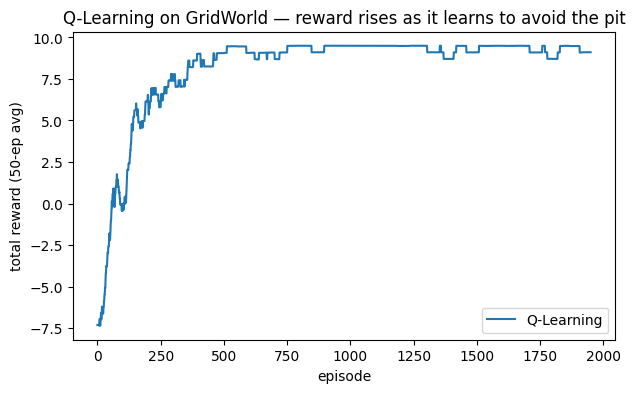

Greedy policy: avg reward=9.50  goal reached 100/100 episodes


In [4]:
agent_q = QLearning(
    n_states=GRID.n_states, n_actions=GRID.N_ACTIONS,
    alpha=0.1, gamma=0.99,
    epsilon=1.0, epsilon_min=0.01, epsilon_decay=0.995,
    random_state=0,
)
agent_q.train(GRID, n_episodes=2000)

# Smooth and plot learning curve
rewards_q = np.array(agent_q.episode_rewards_)
smoothed_q = np.convolve(rewards_q, np.ones(50)/50, mode="valid")
plt.plot(smoothed_q, label="Q-Learning")
plt.xlabel("episode"); plt.ylabel("total reward (50-ep avg)")
plt.title("Q-Learning on GridWorld — reward rises as it learns to avoid the pit")
plt.legend(); plt.show()

# Greedy policy evaluation
total, n_success = 0, 0
for _ in range(100):
    s = GRID.reset(); done = False; ep_r = 0
    for _ in range(50):
        a = agent_q.select_action(s, greedy=True)
        s, r, done = GRID.step(a); ep_r += r
        if done: break
    total += ep_r; n_success += (done and r > 0)
print(f"Greedy policy: avg reward={total/100:.2f}  goal reached {n_success}/100 episodes")


## 3. Double Q-Learning — fix over-estimation bias

Standard Q-Learning uses the same Q-table to select *and* evaluate the
greedy action, which systematically over-estimates values. Double
Q-Learning maintains *two* tables and decouples selection from
evaluation.

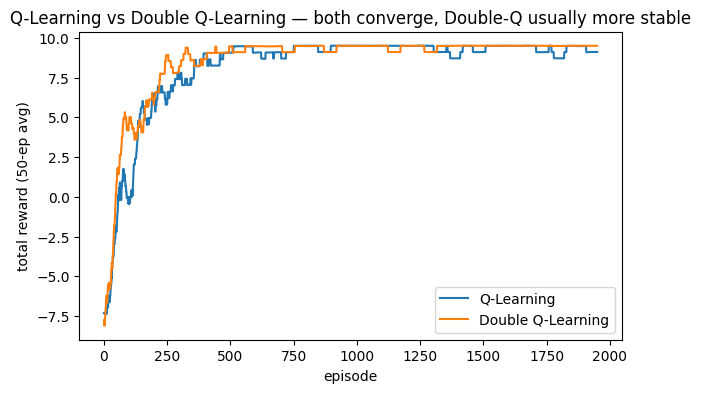

In [5]:
agent_dq = DoubleQLearning(
    n_states=GRID.n_states, n_actions=GRID.N_ACTIONS,
    alpha=0.1, gamma=0.99,
    epsilon=1.0, epsilon_min=0.01, epsilon_decay=0.995,
    random_state=0,
)
agent_dq.train(GRID, n_episodes=2000)

rewards_dq = np.array(agent_dq.episode_rewards_)
smoothed_dq = np.convolve(rewards_dq, np.ones(50)/50, mode="valid")

plt.plot(smoothed_q[:len(smoothed_dq)], label="Q-Learning")
plt.plot(smoothed_dq, label="Double Q-Learning")
plt.xlabel("episode"); plt.ylabel("total reward (50-ep avg)")
plt.title("Q-Learning vs Double Q-Learning — both converge, Double-Q usually more stable")
plt.legend(); plt.show()


## 4. DQN — Q-Learning scaled to neural networks

DQN replaces the lookup table with a neural network, making it
applicable to high-dimensional state spaces. Two key stabilisation
tricks: **experience replay** (break temporal correlations by sampling
random mini-batches from a buffer), and a **target network** (a
frozen copy of Q that's only synced every N steps).

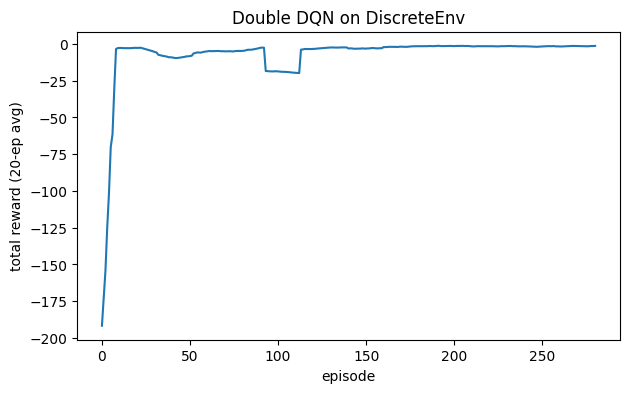

Final 20-ep avg: -1.3  (max per episode: -0.4)


In [6]:
agent_dqn = DQN(
    state_dim=DISC_ENV.state_dim,
    n_actions=DISC_ENV.N_ACTIONS,
    hidden_sizes=[64, 64],
    lr=1e-3, gamma=0.99,
    epsilon=1.0, epsilon_min=0.01, epsilon_decay=0.998,
    batch_size=32, buffer_capacity=5000,
    target_update=100,
    double_dqn=True,    # Double-DQN variant
    random_state=0,
)
agent_dqn.train(DISC_ENV, n_episodes=300)

rewards_dqn = np.array(agent_dqn.episode_rewards_)
smoothed_dqn = np.convolve(rewards_dqn, np.ones(20)/20, mode="valid")
plt.plot(smoothed_dqn)
plt.xlabel("episode"); plt.ylabel("total reward (20-ep avg)")
plt.title("Double DQN on DiscreteEnv")
plt.show()
print(f"Final 20-ep avg: {smoothed_dqn[-1]:.1f}  (max per episode: {max(rewards_dqn[-20:]):.1f})")


## 5. DDPG — continuous actions via actor-critic

The Deterministic Policy Gradient actor-critic: a **critic** estimates
Q(s,a) for any action (not just the discrete argmax), and an **actor**
is trained to output the action that maximises the critic's estimate.
Exploration uses Ornstein-Uhlenbeck noise added to the deterministic
action.

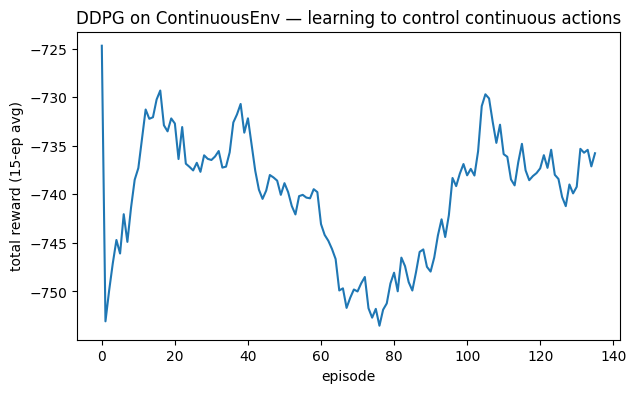

In [7]:
env_ddpg = ContinuousEnv(max_steps=200)
agent_ddpg = DDPG(
    state_dim=env_ddpg.state_dim, action_dim=env_ddpg.action_dim,
    action_low=env_ddpg.ACTION_LOW, action_high=env_ddpg.ACTION_HIGH,
    hidden_sizes=[64, 64], actor_lr=1e-3, critic_lr=1e-3,
    batch_size=32, buffer_capacity=5000, warmup_steps=100,
    random_state=0,
)
agent_ddpg.train(env_ddpg, n_episodes=150)

rewards_ddpg = np.array(agent_ddpg.episode_rewards_)
smoothed_ddpg = np.convolve(rewards_ddpg, np.ones(15)/15, mode="valid")
plt.plot(smoothed_ddpg)
plt.xlabel("episode"); plt.ylabel("total reward (15-ep avg)")
plt.title("DDPG on ContinuousEnv — learning to control continuous actions")
plt.show()


## 6. TD3 — Twin Delayed Deep Deterministic policy gradient

TD3 fixes DDPG's systematic over-estimation by (1) using **twin
critics** and taking the minimum of their predictions, (2) adding
noise to the target action (smoothing the policy update), and (3)
updating the **actor less frequently** than the critics (delayed
updates).

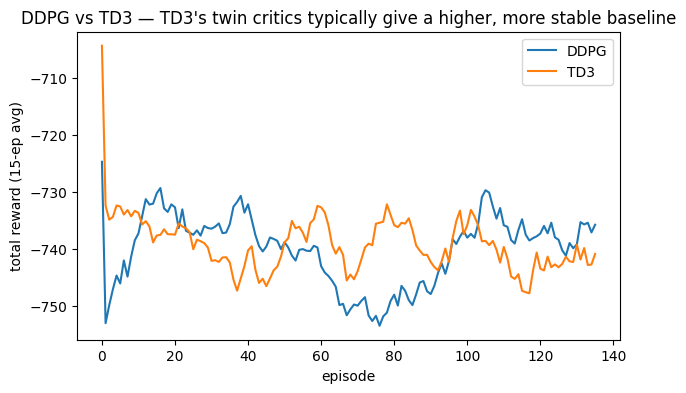

In [8]:
env_td3 = ContinuousEnv(max_steps=200)
agent_td3 = TD3(
    state_dim=env_td3.state_dim, action_dim=env_td3.action_dim,
    action_low=env_td3.ACTION_LOW, action_high=env_td3.ACTION_HIGH,
    hidden_sizes=[64, 64], actor_lr=1e-3, critic_lr=1e-3,
    batch_size=32, buffer_capacity=5000, warmup_steps=100,
    policy_delay=2,   # update actor every 2 critic steps
    random_state=0,
)
agent_td3.train(env_td3, n_episodes=150)

rewards_td3 = np.array(agent_td3.episode_rewards_)
smoothed_td3 = np.convolve(rewards_td3, np.ones(15)/15, mode="valid")

n = min(len(smoothed_ddpg), len(smoothed_td3))
plt.plot(smoothed_ddpg[:n], label="DDPG")
plt.plot(smoothed_td3[:n], label="TD3")
plt.xlabel("episode"); plt.ylabel("total reward (15-ep avg)")
plt.title("DDPG vs TD3 — TD3's twin critics typically give a higher, more stable baseline")
plt.legend(); plt.show()


## 7. PPO — Proximal Policy Optimization

PPO is arguably the most widely deployed policy-gradient algorithm
in practice (it's what OpenAI used to train ChatGPT-style RLHF). The
key innovation: clip the policy update ratio to a small range so the
policy can never change too drastically in a single step.

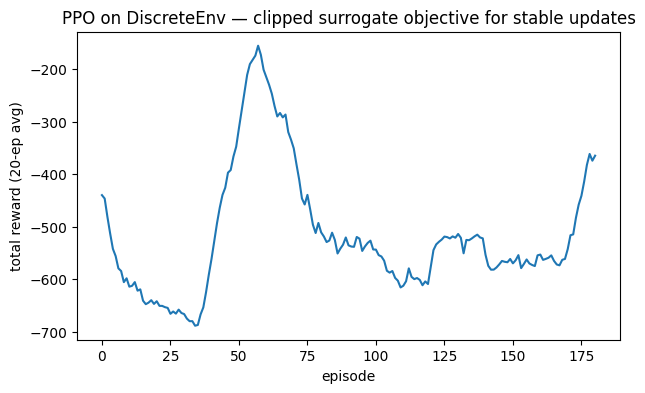

In [9]:
env_ppo = DiscreteEnv(max_steps=200)
agent_ppo = PPO(
    state_dim=env_ppo.state_dim, n_actions=env_ppo.N_ACTIONS,
    hidden_sizes=[64, 64], actor_lr=3e-4, critic_lr=1e-3,
    gamma=0.99, lam=0.95, clip_eps=0.2,
    n_epochs=4, batch_size=32, rollout_len=256,
    random_state=0,
)
agent_ppo.train(env_ppo, n_episodes=200)

rewards_ppo = np.array(agent_ppo.episode_rewards_)
smoothed_ppo = np.convolve(rewards_ppo, np.ones(20)/20, mode="valid")
plt.plot(smoothed_ppo)
plt.xlabel("episode"); plt.ylabel("total reward (20-ep avg)")
plt.title("PPO on DiscreteEnv — clipped surrogate objective for stable updates")
plt.show()


## 8. SAC — Soft Actor-Critic

SAC maximises expected return *and* entropy simultaneously — the agent
is encouraged to be both effective and uncertain (exploratory). The
temperature parameter α is tuned automatically throughout training.

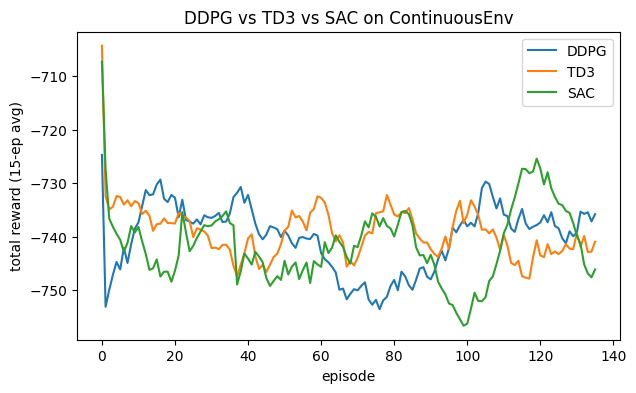

In [10]:
env_sac = ContinuousEnv(max_steps=200)
agent_sac = SAC(
    state_dim=env_sac.state_dim, action_dim=env_sac.action_dim,
    action_low=env_sac.ACTION_LOW, action_high=env_sac.ACTION_HIGH,
    hidden_sizes=[64, 64],
    batch_size=32, buffer_capacity=5000, warmup_steps=100,
    auto_alpha=True,   # temperature auto-tuned
    random_state=0,
)
agent_sac.train(env_sac, n_episodes=150)

rewards_sac = np.array(agent_sac.episode_rewards_)
smoothed_sac = np.convolve(rewards_sac, np.ones(15)/15, mode="valid")

n = min(len(smoothed_ddpg), len(smoothed_td3), len(smoothed_sac))
plt.plot(smoothed_ddpg[:n], label="DDPG")
plt.plot(smoothed_td3[:n], label="TD3")
plt.plot(smoothed_sac[:n], label="SAC")
plt.xlabel("episode"); plt.ylabel("total reward (15-ep avg)")
plt.title("DDPG vs TD3 vs SAC on ContinuousEnv")
plt.legend(); plt.show()


## Next steps

- See **`01_supervised_learning.ipynb`** for regression, classification, and ensembles
- See **`02_unsupervised_learning.ipynb`** for clustering, PCA, t-SNE
- See **`03_bayesian_methods.ipynb`** for Naive Bayes, Gaussian Processes, HMMs
- See **`05_neural_networks.ipynb`** for MLPs, RNNs, CNNs, Transformers, and GANs

⭐ If this was useful, star the repo:
https://github.com/Mattral/ML-AI-Algorithms-from-scratch
